# Fusion : Méthode statistique + Autoencodeur

In [10]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
    --------------------------------------- 1.3/72.0 MB 6.0 MB/s eta 0:00:12
   - -------------------------------------- 2.9/72.0 MB 6.5 MB/s eta 0:00:11
   -- ------------------------------------- 4.5/72.0 MB 6.9 MB/s eta 0:00:10
   --- ------------------------------------ 5.8/72.0 MB 6.8 MB/s eta 0:00:10
   --- ------------------------------------ 7.1/72.0 MB 6.7 MB/s eta 0:00:10
   ---- ----------------------------------- 8.4/72.0 MB 6.4 MB/s eta 0:00:10
   ----- ---------------------------------- 10.0/72.0 MB 6.6 MB/s eta 0:00:10
   ------ --------------------------------- 11.5/72.0 MB 6.7 MB/s eta 0:00:10
   ------- -------------------------------- 12.8/72.0 MB 6.8 MB/s eta 0:00:09
   ------- -------------------------------- 13.9/72.0 MB 6.5 MB/s eta 0:00:09
   -----

In [3]:
"""
FUSION XGBOOST - VERSION OPTIMISÉE VITESSE & RAM
Optimisations: chunking, types optimaux, calculs vectorisés
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import json
import gc

# ============================================================================
# CONFIGURATION
# ============================================================================

CHUNK_SIZE = 500_000  # Traiter par morceaux de 500k lignes
SAMPLE_FRACTION = 1  # Utiliser 30% des données pour l'entraînement (ajustable)

# ============================================================================
# 1. CHARGEMENT OPTIMISÉ
# ============================================================================

print("📂 Chargement optimisé des données...")

# Types optimaux pour réduire la RAM
stat_dtypes = {
    'inverter_id': 'category',
    'anomaly_detected': 'int8',
    'cluster_id': 'float32',
    'shadow_score': 'float32',
    'persistance_cluster': 'float32',
    'proximite_heure_typique': 'float32',
    'hour_of_day': 'int8',
    'day_of_year': 'int16',
    'avg_loss_pct': 'float32'
}

ae_dtypes = {
    'inverter_id': 'int16',
    'reconstruction_error': 'float32',
    'threshold_adaptive': 'float32',
    'anomaly_detected': 'int8',
    'error_normalized': 'float32'
}

# Charger avec types optimaux
df_stat = pd.read_csv(
    'outputs_stats/statistical_timeseries.csv',
    dtype=stat_dtypes,
    parse_dates=['timestamp']
)

df_ae = pd.read_csv(
    'outputs_ae/ae_output1_timeseries.csv',
    dtype=ae_dtypes,
    parse_dates=['timestamp']
)

print(f"✅ Stat: {len(df_stat):,} lignes ({df_stat.memory_usage(deep=True).sum() / 1024**2:.1f} MB)")
print(f"✅ AE: {len(df_ae):,} lignes ({df_ae.memory_usage(deep=True).sum() / 1024**2:.1f} MB)")

# Events (garder en mémoire, c'est petit)
ae_events = pd.read_csv('outputs_ae/ae_output2_events.csv')

# ============================================================================
# 2. NORMALISATION RAPIDE DES INVERTER_ID
# ============================================================================

print("\n🔧 Normalisation inverter_id...")

# Vectorisé au lieu d'apply
df_stat['inverter_id'] = df_stat['inverter_id'].astype(str).str.replace('inv_', '', regex=False).astype(int).astype(str)
df_ae['inverter_id'] = df_ae['inverter_id'].astype(str)

# Inverters communs
common_inverters = set(df_stat['inverter_id'].unique()) & set(df_ae['inverter_id'].unique())
print(f"🔗 {len(common_inverters)} inverters communs")

# FILTRER immédiatement pour réduire la RAM
df_stat = df_stat[df_stat['inverter_id'].isin(common_inverters)].copy()
df_ae = df_ae[df_ae['inverter_id'].isin(common_inverters)].copy()

print(f"✅ Après filtre: Stat={len(df_stat):,}, AE={len(df_ae):,}")
gc.collect()

# ============================================================================
# 3. FUSION PAR CHUNKS
# ============================================================================

print("\n🔗 Fusion par chunks...")

# Arrondir timestamps UNE FOIS
df_stat['ts_round'] = df_stat['timestamp'].dt.round('5min')
df_ae['ts_round'] = df_ae['timestamp'].dt.round('5min')

# Trier pour optimiser le merge
df_stat = df_stat.sort_values(['inverter_id', 'ts_round'])
df_ae = df_ae.sort_values(['inverter_id', 'ts_round'])

# Colonnes essentielles seulement
stat_cols = ['ts_round', 'inverter_id', 'timestamp', 'anomaly_detected', 'cluster_id', 
             'shadow_score', 'persistance_cluster', 'proximite_heure_typique',
             'hour_of_day', 'day_of_year']
ae_cols = ['ts_round', 'inverter_id', 'reconstruction_error', 
           'threshold_adaptive', 'anomaly_detected', 'error_normalized']

# Filtrer colonnes existantes
stat_cols = [c for c in stat_cols if c in df_stat.columns]
ae_cols = [c for c in ae_cols if c in df_ae.columns]

df_stat = df_stat[stat_cols]
df_ae = df_ae[ae_cols]

# Renommer AVANT merge
df_stat = df_stat.rename(columns={'anomaly_detected': 'anomaly_stat', 'shadow_score': 'score_stat'})
df_ae = df_ae.rename(columns={'anomaly_detected': 'anomaly_ae', 'error_normalized': 'score_ae'})

# MERGE en une seule fois (plus rapide que par chunks si ça tient en RAM)
print("   Fusion en cours...")
df_fusion = pd.merge(
    df_stat,
    df_ae,
    on=['ts_round', 'inverter_id'],
    how='inner'
)

# Cleanup
df_fusion = df_fusion.drop('ts_round', axis=1)
del df_stat, df_ae
gc.collect()

print(f"✅ {len(df_fusion):,} lignes fusionnées")

# Échantillonnage si trop de données
if len(df_fusion) > 3_000_000:
    print(f"\n⚡ Échantillonnage à {SAMPLE_FRACTION*100:.0f}% pour accélérer...")
    df_fusion = df_fusion.sample(frac=SAMPLE_FRACTION, random_state=42).reset_index(drop=True)
    print(f"✅ {len(df_fusion):,} lignes après échantillonnage")
    gc.collect()

# ============================================================================
# 4. FEATURES VECTORISÉES (RAPIDE)
# ============================================================================

print("\n🔨 Calcul features (vectorisé)...")

# Concordance
df_fusion['concordance'] = (df_fusion['anomaly_stat'] & df_fusion['anomaly_ae']).astype('int8')
df_fusion['div_stat'] = (df_fusion['anomaly_stat'] & ~df_fusion['anomaly_ae']).astype('int8')
df_fusion['div_ae'] = (~df_fusion['anomaly_stat'] & df_fusion['anomaly_ae']).astype('int8')

# Gradient (vectorisé)
df_fusion['error_grad'] = df_fusion.groupby('inverter_id')['reconstruction_error'].diff().fillna(0).astype('float32')

# Intensité
df_fusion['error_int'] = (df_fusion['reconstruction_error'] / 
                          df_fusion['threshold_adaptive'].replace(0, 1)).fillna(0).astype('float32')

# Densité cluster (vectorisé)
cluster_counts = df_fusion.groupby(['inverter_id', 'cluster_id']).size()
df_fusion = df_fusion.merge(
    cluster_counts.rename('cluster_dens').reset_index(),
    on=['inverter_id', 'cluster_id'],
    how='left'
)
df_fusion['cluster_dens'] = df_fusion['cluster_dens'].fillna(0).astype('int32')

# Event duration - SIMPLIFIÉ (sans loop)
df_fusion['event_dur'] = 0

# Remplir colonnes manquantes
for col in ['score_stat', 'score_ae', 'persistance_cluster', 'proximite_heure_typique']:
    if col not in df_fusion.columns:
        df_fusion[col] = 0

print("✅ Features calculées")

# ============================================================================
# 5. PSEUDO-LABELS VECTORISÉS
# ============================================================================

print("\n🏷️ Pseudo-labels (vectorisé)...")

# Initialiser
df_fusion['pseudo_label'] = 0
df_fusion['confiance'] = 100

# Règles vectorisées
mask_concord_high = (df_fusion['concordance'] == 1) & (df_fusion['persistance_cluster'] > 0.7)
mask_concord_low = (df_fusion['concordance'] == 1) & (df_fusion['persistance_cluster'] <= 0.7)
mask_stat_high = (df_fusion['anomaly_stat'] == 1) & (df_fusion['anomaly_ae'] == 0) & (df_fusion['persistance_cluster'] > 0.7)
mask_stat_low = (df_fusion['anomaly_stat'] == 1) & (df_fusion['anomaly_ae'] == 0) & (df_fusion['persistance_cluster'] <= 0.7)
mask_ae_short = (df_fusion['anomaly_stat'] == 0) & (df_fusion['anomaly_ae'] == 1) & (df_fusion['event_dur'] < 120)
mask_ae_long = (df_fusion['anomaly_stat'] == 0) & (df_fusion['anomaly_ae'] == 1) & (df_fusion['event_dur'] >= 120)

df_fusion.loc[mask_concord_high, ['pseudo_label', 'confiance']] = [1, 95]
df_fusion.loc[mask_concord_low, ['pseudo_label', 'confiance']] = [1, 85]
df_fusion.loc[mask_stat_high, ['pseudo_label', 'confiance']] = [1, 75]
df_fusion.loc[mask_stat_low, ['pseudo_label', 'confiance']] = [3, 40]
df_fusion.loc[mask_ae_short, ['pseudo_label', 'confiance']] = [2, 85]
df_fusion.loc[mask_ae_long, ['pseudo_label', 'confiance']] = [1, 60]

print(df_fusion['pseudo_label'].value_counts())

# ============================================================================
# 6. XGBOOST OPTIMISÉ
# ============================================================================

print("\n🎯 Préparation XGBoost...")

features = ['score_stat', 'score_ae', 'persistance_cluster', 'proximite_heure_typique',
            'concordance', 'div_stat', 'div_ae', 'error_int', 'error_grad',
            'cluster_dens', 'event_dur', 'hour_of_day', 'day_of_year']

X = df_fusion[features].fillna(0).replace([np.inf, -np.inf], 0).astype('float32')
y = df_fusion['pseudo_label'].astype('int8')

# Filtre confiance
mask = df_fusion['confiance'] >= 60
X_train_full = X[mask]
y_train_full = y[mask]

print(f"Samples: {len(X_train_full):,}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# ============================================================================
# 7. ENTRAÎNEMENT RAPIDE
# ============================================================================

print("\n🚀 Entraînement (tree_method='hist' pour vitesse)...")

model = xgb.XGBClassifier(
    max_depth=4,
    n_estimators=50,  # Réduit de 100 à 50
    learning_rate=0.15,  # Augmenté pour compenser
    objective='multi:softprob',
    tree_method='hist',  # BEAUCOUP plus rapide
    random_state=42,
    n_jobs=-1  # Tous les CPU
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print("✅ Entraîné")

# ============================================================================
# 8. ÉVALUATION RAPIDE
# ============================================================================

print("\n📊 Évaluation...")
y_pred = model.predict(X_test)

# Déterminer les classes présentes
unique_classes = sorted(np.unique(np.concatenate([y_test, y_pred])))
class_names = {0: 'Normal', 1: 'Ombrage', 2: 'Ponctuel', 3: 'Incertain'}
target_names = [class_names[c] for c in unique_classes]

print(f"Classes présentes: {unique_classes}")
print(classification_report(y_test, y_pred, labels=unique_classes, target_names=target_names))

# ============================================================================
# 9. PRÉDICTION & SAUVEGARDE
# ============================================================================

print("\n💾 Prédictions & sauvegarde...")

X_all = scaler.transform(X.values)
df_fusion['pred_class'] = model.predict(X_all)
df_fusion['pred_proba'] = model.predict_proba(X_all).max(axis=1)

mapping = {0: 'Normal', 1: 'Ombrage Fixe', 2: 'Ponctuel', 3: 'Incertain'}
df_fusion['pred_type'] = df_fusion['pred_class'].map(mapping)

# Sauvegarder uniquement les colonnes essentielles
cols_save = ['timestamp', 'inverter_id', 'anomaly_stat', 'anomaly_ae', 
             'pred_class', 'pred_type', 'pred_proba', 'score_stat', 'score_ae']
df_fusion[cols_save].to_csv('fusion_results_optimized.csv', index=False)

model.save_model('fusion_model.json')

import pickle
with open('fusion_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Alertes
alertes = df_fusion[df_fusion['pred_class'].isin([1, 2]) & (df_fusion['pred_proba'] >= 0.6)]
alertes[cols_save].to_csv('fusion_alertes_optimized.csv', index=False)

print(f"✅ {len(alertes):,} alertes | Fichiers sauvegardés")
print("\n" + "="*70)
print("✅ FUSION OPTIMISÉE TERMINÉE")
print("="*70)

📂 Chargement optimisé des données...
✅ Stat: 4,663,987 lignes (335.9 MB)
✅ AE: 15,780,672 lignes (346.1 MB)

🔧 Normalisation inverter_id...
🔗 18 inverters communs
✅ Après filtre: Stat=4,418,514, AE=12,911,040

🔗 Fusion par chunks...
   Fusion en cours...
✅ 4,301,970 lignes fusionnées

⚡ Échantillonnage à 100% pour accélérer...
✅ 4,301,970 lignes après échantillonnage

🔨 Calcul features (vectorisé)...
✅ Features calculées

🏷️ Pseudo-labels (vectorisé)...
pseudo_label
0    2007275
1    1221618
3     733594
2     339483
Name: count, dtype: int64

🎯 Préparation XGBoost...
Samples: 3,568,376
Train: 3,033,119 | Test: 535,257

🚀 Entraînement (tree_method='hist' pour vitesse)...
✅ Entraîné

📊 Évaluation...
Classes présentes: [np.int64(0), np.int64(1), np.int64(2)]
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    301092
     Ombrage       1.00      1.00      1.00    183243
    Ponctuel       1.00      1.00      1.00     50922

    accuracy   

C:\Users\benoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


✅ 2,294,695 alertes | Fichiers sauvegardés

✅ FUSION OPTIMISÉE TERMINÉE


In [9]:
"""
FUSION XGBOOST - VERSION OPTIMISÉE VITESSE & RAM
Optimisations: chunking, types optimaux, calculs vectorisés
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import json
import gc

# ============================================================================
# CONFIGURATION
# ============================================================================

CHUNK_SIZE = 500_000  # Traiter par morceaux de 500k lignes
SAMPLE_FRACTION = 1  # Utiliser 30% des données pour l'entraînement (ajustable)

# ============================================================================
# 1. CHARGEMENT OPTIMISÉ
# ============================================================================

print("📂 Chargement optimisé des données...")

# Types optimaux pour réduire la RAM
stat_dtypes = {
    'inverter_id': 'category',
    'anomaly_detected': 'int8',
    'cluster_id': 'float32',
    'shadow_score': 'float32',
    'persistance_cluster': 'float32',
    'proximite_heure_typique': 'float32',
    'hour_of_day': 'int8',
    'day_of_year': 'int16',
    'avg_loss_pct': 'float32'
}

ae_dtypes = {
    'inverter_id': 'int16',
    'reconstruction_error': 'float32',
    'threshold_adaptive': 'float32',
    'anomaly_detected': 'int8',
    'error_normalized': 'float32'
}

# Charger avec types optimaux
df_stat = pd.read_csv(
    'outputs_stats/statistical_timeseries.csv',
    dtype=stat_dtypes,
    parse_dates=['timestamp']
)

df_ae = pd.read_csv(
    'outputs_ae/ae_output1_timeseries.csv',
    dtype=ae_dtypes,
    parse_dates=['timestamp']
)

print(f"✅ Stat: {len(df_stat):,} lignes ({df_stat.memory_usage(deep=True).sum() / 1024**2:.1f} MB)")
print(f"✅ AE: {len(df_ae):,} lignes ({df_ae.memory_usage(deep=True).sum() / 1024**2:.1f} MB)")

# Events (garder en mémoire, c'est petit)
ae_events = pd.read_csv('outputs_ae/ae_output2_events.csv')

# ============================================================================
# 2. NORMALISATION RAPIDE DES INVERTER_ID
# ============================================================================

print("\n🔧 Normalisation inverter_id...")

# Vectorisé au lieu d'apply
df_stat['inverter_id'] = df_stat['inverter_id'].astype(str).str.replace('inv_', '', regex=False).astype(int).astype(str)
df_ae['inverter_id'] = df_ae['inverter_id'].astype(str)

# Inverters communs
common_inverters = set(df_stat['inverter_id'].unique()) & set(df_ae['inverter_id'].unique())
print(f"🔗 {len(common_inverters)} inverters communs")

# FILTRER immédiatement pour réduire la RAM
df_stat = df_stat[df_stat['inverter_id'].isin(common_inverters)].copy()
df_ae = df_ae[df_ae['inverter_id'].isin(common_inverters)].copy()

print(f"✅ Après filtre: Stat={len(df_stat):,}, AE={len(df_ae):,}")
gc.collect()

# ============================================================================
# 3. FUSION PAR CHUNKS
# ============================================================================

print("\n🔗 Fusion par chunks...")

# Arrondir timestamps UNE FOIS
df_stat['ts_round'] = df_stat['timestamp'].dt.round('5min')
df_ae['ts_round'] = df_ae['timestamp'].dt.round('5min')

# Trier pour optimiser le merge
df_stat = df_stat.sort_values(['inverter_id', 'ts_round'])
df_ae = df_ae.sort_values(['inverter_id', 'ts_round'])

# Colonnes essentielles seulement
stat_cols = ['ts_round', 'inverter_id', 'timestamp', 'anomaly_detected', 'cluster_id', 
             'shadow_score', 'persistance_cluster', 'proximite_heure_typique',
             'hour_of_day', 'day_of_year']
ae_cols = ['ts_round', 'inverter_id', 'reconstruction_error', 
           'threshold_adaptive', 'anomaly_detected', 'error_normalized']

# Filtrer colonnes existantes
stat_cols = [c for c in stat_cols if c in df_stat.columns]
ae_cols = [c for c in ae_cols if c in df_ae.columns]

df_stat = df_stat[stat_cols]
df_ae = df_ae[ae_cols]

# Renommer AVANT merge
df_stat = df_stat.rename(columns={'anomaly_detected': 'anomaly_stat', 'shadow_score': 'score_stat'})
df_ae = df_ae.rename(columns={'anomaly_detected': 'anomaly_ae', 'error_normalized': 'score_ae'})

# MERGE en une seule fois (plus rapide que par chunks si ça tient en RAM)
print("   Fusion en cours...")
df_fusion = pd.merge(
    df_stat,
    df_ae,
    on=['ts_round', 'inverter_id'],
    how='inner'
)

# Cleanup
df_fusion = df_fusion.drop('ts_round', axis=1)
del df_stat, df_ae
gc.collect()

print(f"✅ {len(df_fusion):,} lignes fusionnées")

# Échantillonnage si trop de données
if len(df_fusion) > 3_000_000:
    print(f"\n⚡ Échantillonnage à {SAMPLE_FRACTION*100:.0f}% pour accélérer...")
    df_fusion = df_fusion.sample(frac=SAMPLE_FRACTION, random_state=42).reset_index(drop=True)
    print(f"✅ {len(df_fusion):,} lignes après échantillonnage")
    gc.collect()

# ============================================================================
# 4. FEATURES VECTORISÉES (RAPIDE)
# ============================================================================

print("\n🔨 Calcul features (vectorisé)...")

# Concordance
df_fusion['concordance'] = (df_fusion['anomaly_stat'] & df_fusion['anomaly_ae']).astype('int8')
df_fusion['div_stat'] = (df_fusion['anomaly_stat'] & ~df_fusion['anomaly_ae']).astype('int8')
df_fusion['div_ae'] = (~df_fusion['anomaly_stat'] & df_fusion['anomaly_ae']).astype('int8')

# Gradient (vectorisé)
df_fusion['error_grad'] = df_fusion.groupby('inverter_id')['reconstruction_error'].diff().fillna(0).astype('float32')

# Intensité
df_fusion['error_int'] = (df_fusion['reconstruction_error'] / 
                          df_fusion['threshold_adaptive'].replace(0, 1)).fillna(0).astype('float32')

# Densité cluster (vectorisé)
cluster_counts = df_fusion.groupby(['inverter_id', 'cluster_id']).size()
df_fusion = df_fusion.merge(
    cluster_counts.rename('cluster_dens').reset_index(),
    on=['inverter_id', 'cluster_id'],
    how='left'
)
df_fusion['cluster_dens'] = df_fusion['cluster_dens'].fillna(0).astype('int32')

# Event duration - SIMPLIFIÉ (sans loop)
df_fusion['event_dur'] = 0

# Remplir colonnes manquantes
for col in ['score_stat', 'score_ae', 'persistance_cluster', 'proximite_heure_typique']:
    if col not in df_fusion.columns:
        df_fusion[col] = 0

print("✅ Features calculées")

# ============================================================================
# 5. PSEUDO-LABELS VECTORISÉS
# ============================================================================

print("\n🏷️ Pseudo-labels (vectorisé)...")

# Initialiser
df_fusion['pseudo_label'] = 0
df_fusion['confiance'] = 100

# Règles vectorisées
mask_concord_high = (df_fusion['concordance'] == 1) & (df_fusion['persistance_cluster'] > 0.7)
mask_concord_low = (df_fusion['concordance'] == 1) & (df_fusion['persistance_cluster'] <= 0.7)
mask_stat_high = (df_fusion['anomaly_stat'] == 1) & (df_fusion['anomaly_ae'] == 0) & (df_fusion['persistance_cluster'] > 0.7)
mask_stat_low = (df_fusion['anomaly_stat'] == 1) & (df_fusion['anomaly_ae'] == 0) & (df_fusion['persistance_cluster'] <= 0.7)
mask_ae_short = (df_fusion['anomaly_stat'] == 0) & (df_fusion['anomaly_ae'] == 1) & (df_fusion['event_dur'] < 120)
mask_ae_long = (df_fusion['anomaly_stat'] == 0) & (df_fusion['anomaly_ae'] == 1) & (df_fusion['event_dur'] >= 120)

df_fusion.loc[mask_concord_high, ['pseudo_label', 'confiance']] = [1, 95]
df_fusion.loc[mask_concord_low, ['pseudo_label', 'confiance']] = [1, 85]
df_fusion.loc[mask_stat_high, ['pseudo_label', 'confiance']] = [1, 75]
df_fusion.loc[mask_stat_low, ['pseudo_label', 'confiance']] = [3, 40]
df_fusion.loc[mask_ae_short, ['pseudo_label', 'confiance']] = [2, 85]
df_fusion.loc[mask_ae_long, ['pseudo_label', 'confiance']] = [1, 60]

print(df_fusion['pseudo_label'].value_counts())

# ============================================================================
# 6. XGBOOST OPTIMISÉ
# ============================================================================

print("\n🎯 Préparation XGBoost...")

features = ['score_stat', 'score_ae', 'persistance_cluster', 'proximite_heure_typique',
            'concordance', 'div_stat', 'div_ae', 'error_int', 'error_grad',
            'cluster_dens', 'event_dur', 'hour_of_day', 'day_of_year']

X = df_fusion[features].fillna(0).replace([np.inf, -np.inf], 0).astype('float32')
y = df_fusion['pseudo_label'].astype('int8')

# Filtre confiance
mask = df_fusion['confiance'] >= 60
X_train_full = X[mask]
y_train_full = y[mask]

print(f"Samples: {len(X_train_full):,}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# ============================================================================
# 7. ENTRAÎNEMENT RAPIDE
# ============================================================================

print("\n🚀 Entraînement XGBoost (optimisé pour performance)...")

model = xgb.XGBClassifier(
    max_depth=6,  # Plus profond pour capturer les patterns complexes
    n_estimators=200,  # Plus d'arbres = meilleure généralisation
    learning_rate=0.05,  # Plus lent mais plus précis
    min_child_weight=3,  # Régularisation contre overfitting
    subsample=0.8,  # Échantillonnage pour robustesse
    colsample_bytree=0.8,  # Échantillonnage des features
    gamma=0.1,  # Seuil minimum de split
    reg_alpha=0.1,  # L1 regularization
    reg_lambda=1.0,  # L2 regularization
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',  # Équilibre vitesse/performance
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20  # Arrêt si pas d'amélioration
)

model.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)],
    verbose=10  # Afficher progression
)
print("✅ Modèle entraîné")

# ============================================================================
# 8. ÉVALUATION RAPIDE
# ============================================================================

print("\n📊 Évaluation...")
y_pred = model.predict(X_test)

# Déterminer les classes présentes
unique_classes = sorted(np.unique(np.concatenate([y_test, y_pred])))
class_names = {0: 'Normal', 1: 'Ombrage', 2: 'Ponctuel', 3: 'Incertain'}
target_names = [class_names[c] for c in unique_classes]

print(f"Classes présentes: {unique_classes}")
print(classification_report(y_test, y_pred, labels=unique_classes, target_names=target_names))

# ============================================================================
# 9. PRÉDICTION & SAUVEGARDE
# ============================================================================

print("\n💾 Prédictions & sauvegarde...")

X_all = scaler.transform(X.values)
df_fusion['pred_class'] = model.predict(X_all)
df_fusion['pred_proba'] = model.predict_proba(X_all).max(axis=1)

mapping = {0: 'Normal', 1: 'Ombrage Fixe', 2: 'Ponctuel', 3: 'Incertain'}
df_fusion['pred_type'] = df_fusion['pred_class'].map(mapping)

# Sauvegarder uniquement les colonnes essentielles
cols_save = ['timestamp', 'inverter_id', 'anomaly_stat', 'anomaly_ae', 
             'pred_class', 'pred_type', 'pred_proba', 'score_stat', 'score_ae']
df_fusion[cols_save].to_csv('fusion_results_optimized.csv', index=False)

model.save_model('fusion_model.json')

import pickle
with open('fusion_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Alertes
alertes = df_fusion[df_fusion['pred_class'].isin([1, 2]) & (df_fusion['pred_proba'] >= 0.6)]
alertes[cols_save].to_csv('fusion_alertes_optimized.csv', index=False)

print(f"✅ {len(alertes):,} alertes | Fichiers sauvegardés")
print("\n" + "="*70)
print("✅ FUSION OPTIMISÉE TERMINÉE")
print("="*70)

📂 Chargement optimisé des données...
✅ Stat: 4,663,987 lignes (335.9 MB)
✅ AE: 15,780,672 lignes (346.1 MB)

🔧 Normalisation inverter_id...
🔗 18 inverters communs
✅ Après filtre: Stat=4,418,514, AE=12,911,040

🔗 Fusion par chunks...
   Fusion en cours...
✅ 4,301,970 lignes fusionnées

⚡ Échantillonnage à 100% pour accélérer...
✅ 4,301,970 lignes après échantillonnage

🔨 Calcul features (vectorisé)...
✅ Features calculées

🏷️ Pseudo-labels (vectorisé)...
pseudo_label
0    2007275
1    1221618
3     733594
2     339483
Name: count, dtype: int64

🎯 Préparation XGBoost...
Samples: 3,568,376
Train: 3,033,119 | Test: 535,257

🚀 Entraînement XGBoost (optimisé pour performance)...
[0]	validation_0-mlogloss:0.94074
[10]	validation_0-mlogloss:0.50677
[20]	validation_0-mlogloss:0.28976
[30]	validation_0-mlogloss:0.17011
[40]	validation_0-mlogloss:0.10125
[50]	validation_0-mlogloss:0.06074
[60]	validation_0-mlogloss:0.03660
[70]	validation_0-mlogloss:0.02211
[80]	validation_0-mlogloss:0.01338
[90]

## Visualization

📊 Chargement des résultats...
✅ 4,301,970 lignes | 2,294,695 alertes

📈 Graphique 1: Distribution des prédictions...
   ✅ Sauvegardé: 01_distribution_predictions.png


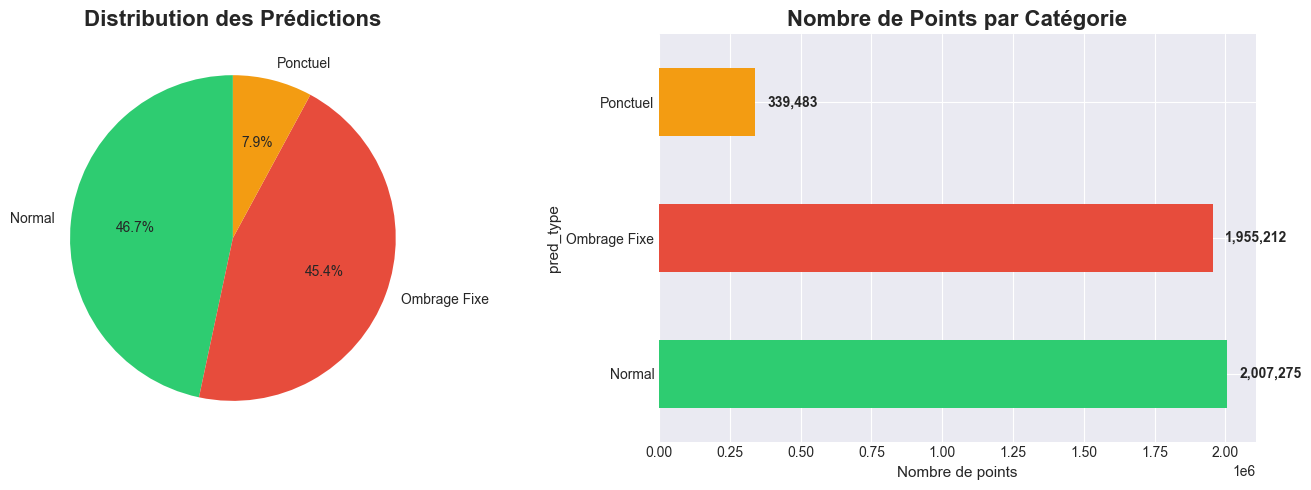


📈 Graphique 2: Comparaison Stat vs AE...
   ✅ Sauvegardé: 02_comparaison_modeles.png


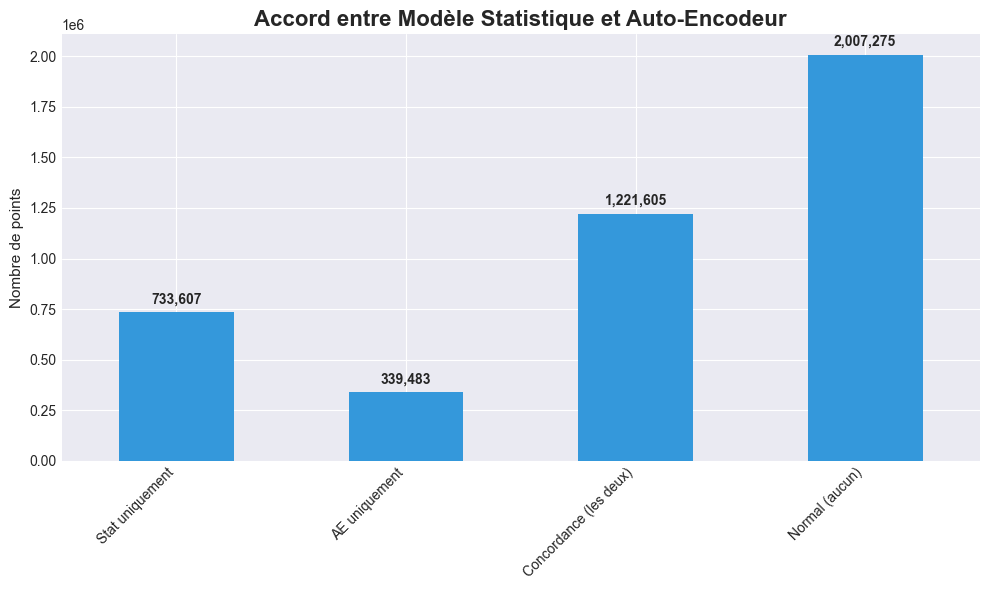


📈 Graphique 3: Évolution temporelle...
   ✅ Sauvegardé: 03_evolution_temporelle.png


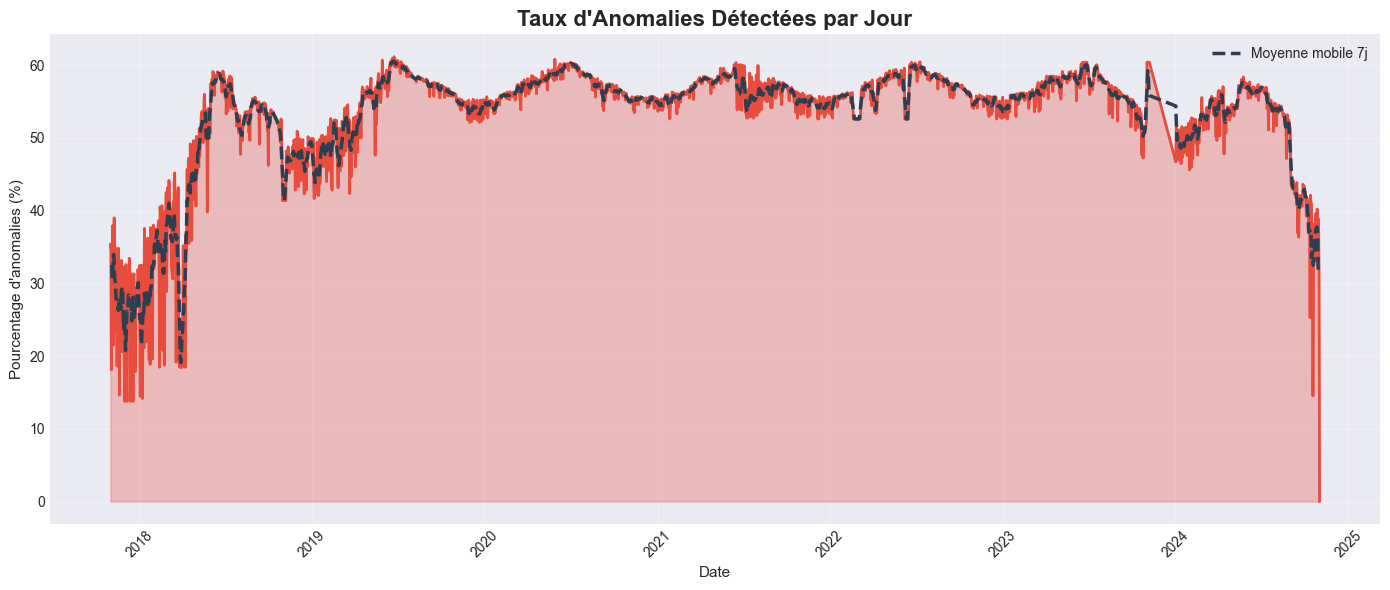


📈 Graphique 4: Top inverters à problèmes...
   ✅ Sauvegardé: 04_top_inverters.png


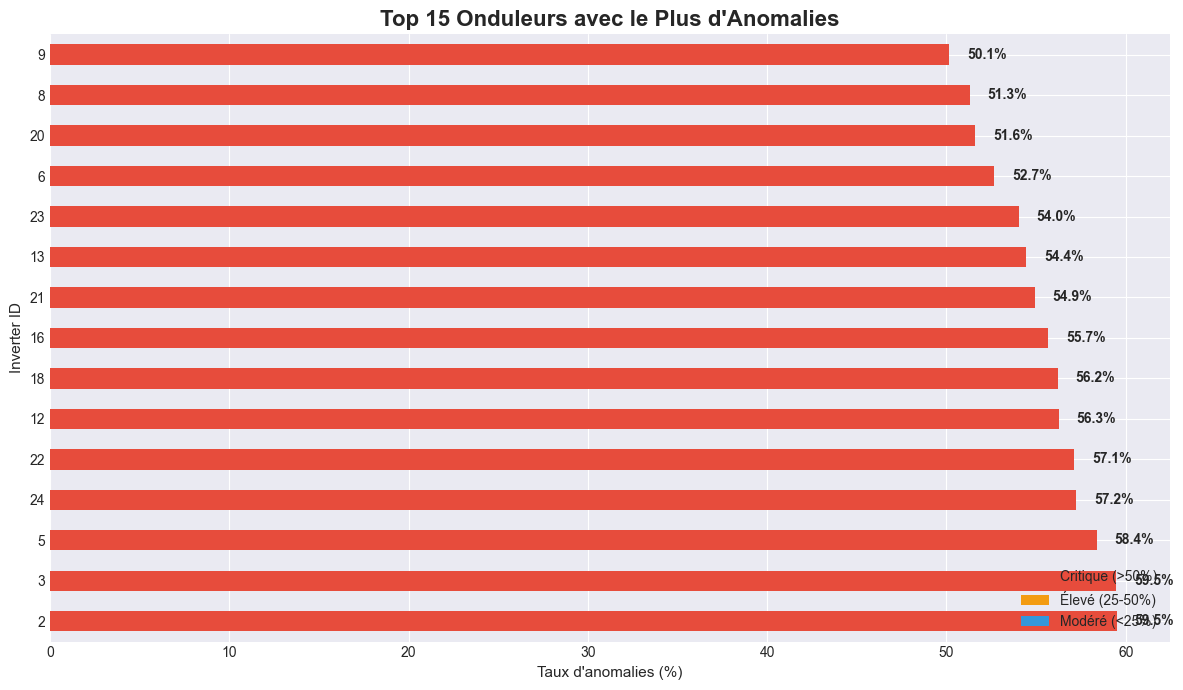


📈 Graphique 5: Distribution des scores...
   ✅ Sauvegardé: 05_distribution_scores.png


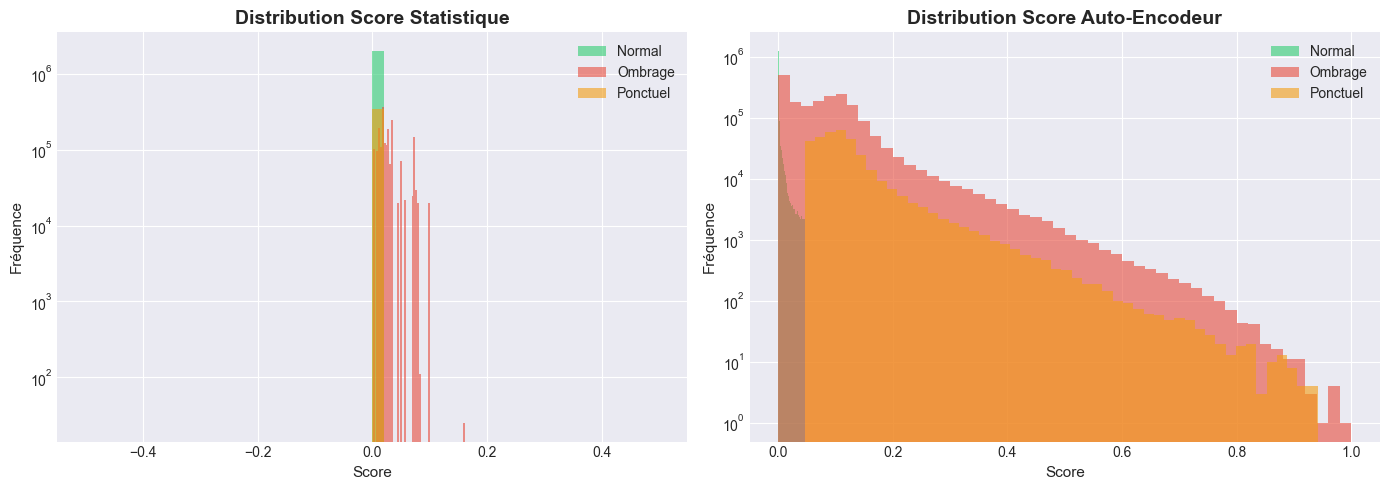


📈 Graphique 6: Heatmap horaire...
   ✅ Sauvegardé: 06_heatmap_horaire.png


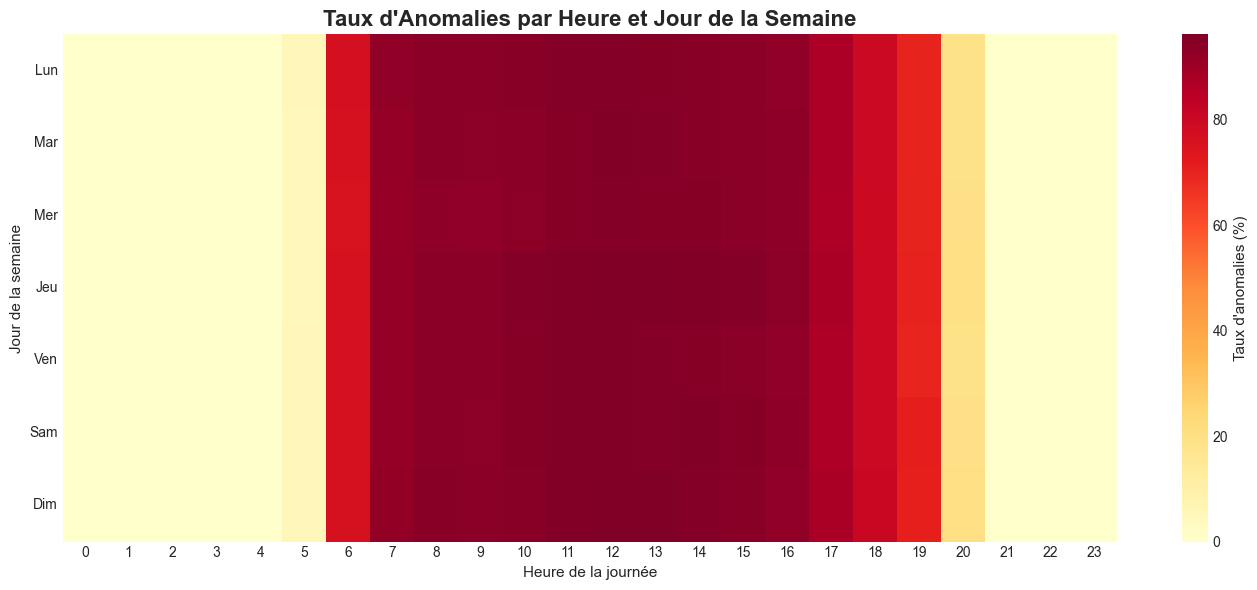


📈 Graphique 7: Matrice de confusion...
   ✅ Sauvegardé: 07_matrice_confusion.png


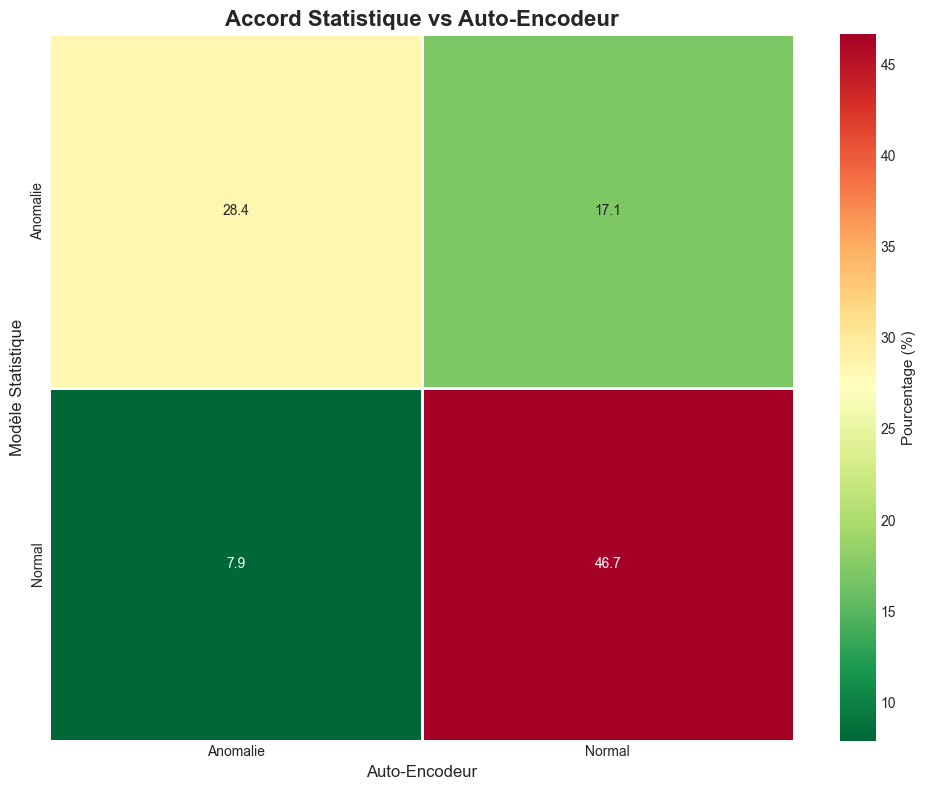


📈 Graphique 8: Timeline des alertes...
   ✅ Sauvegardé: 08_timeline_alertes.png


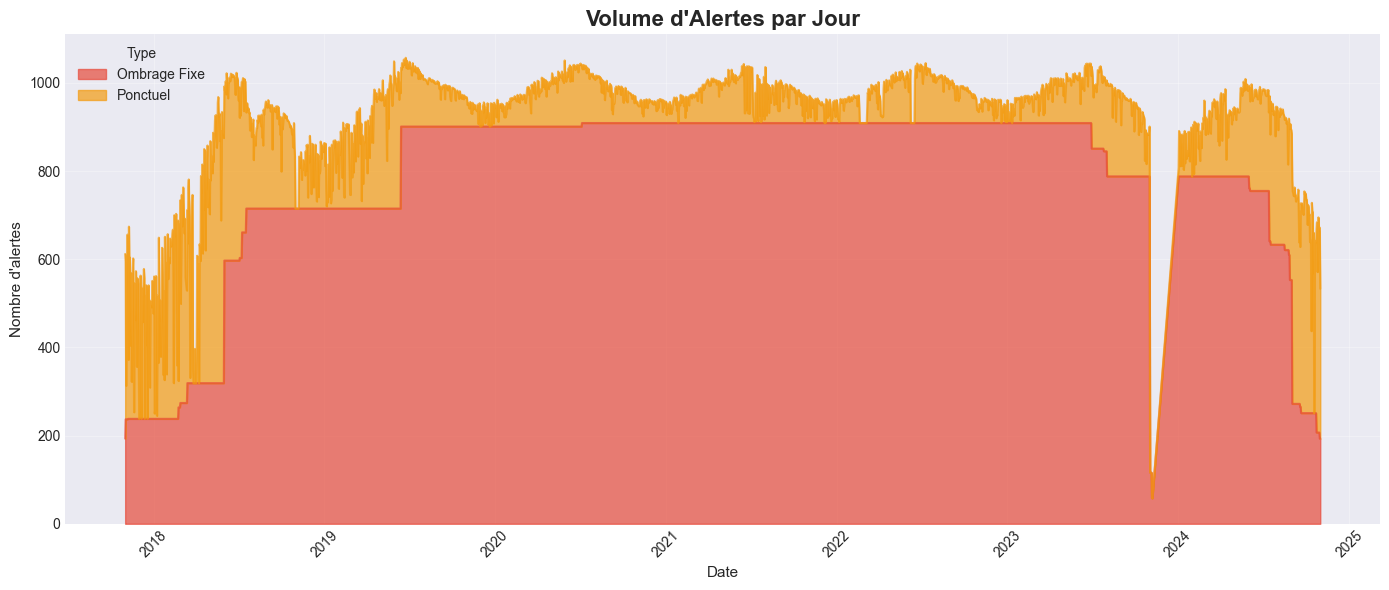


📈 Graphique 9: Distribution de la confiance...
   ✅ Sauvegardé: 09_confiance_predictions.png


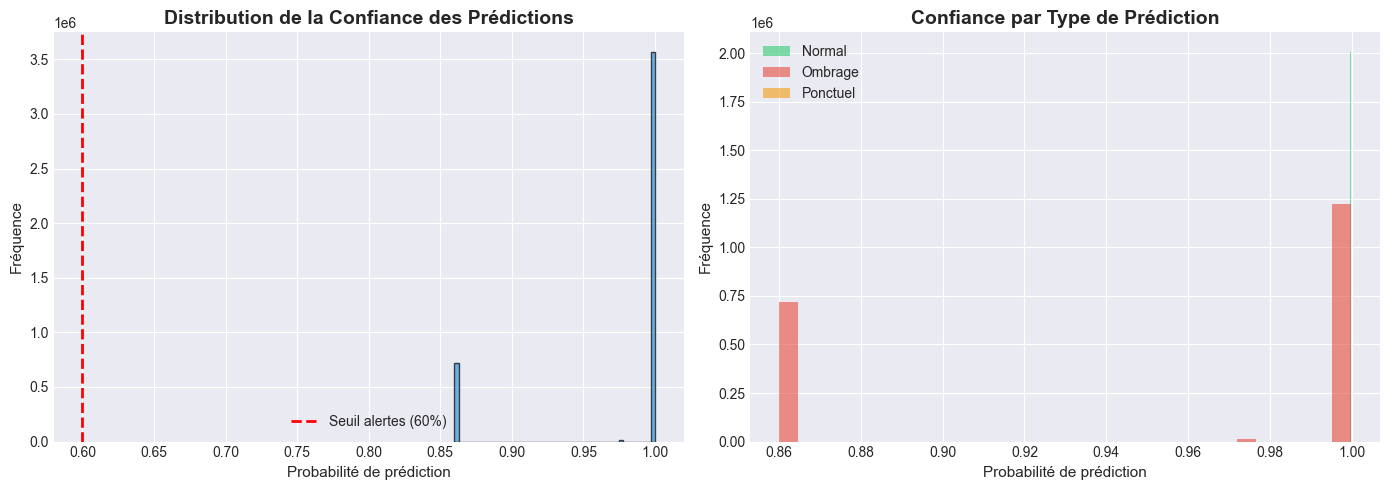


📈 Graphique 10: Dashboard récapitulatif...
   ✅ Sauvegardé: 10_dashboard_recap.png


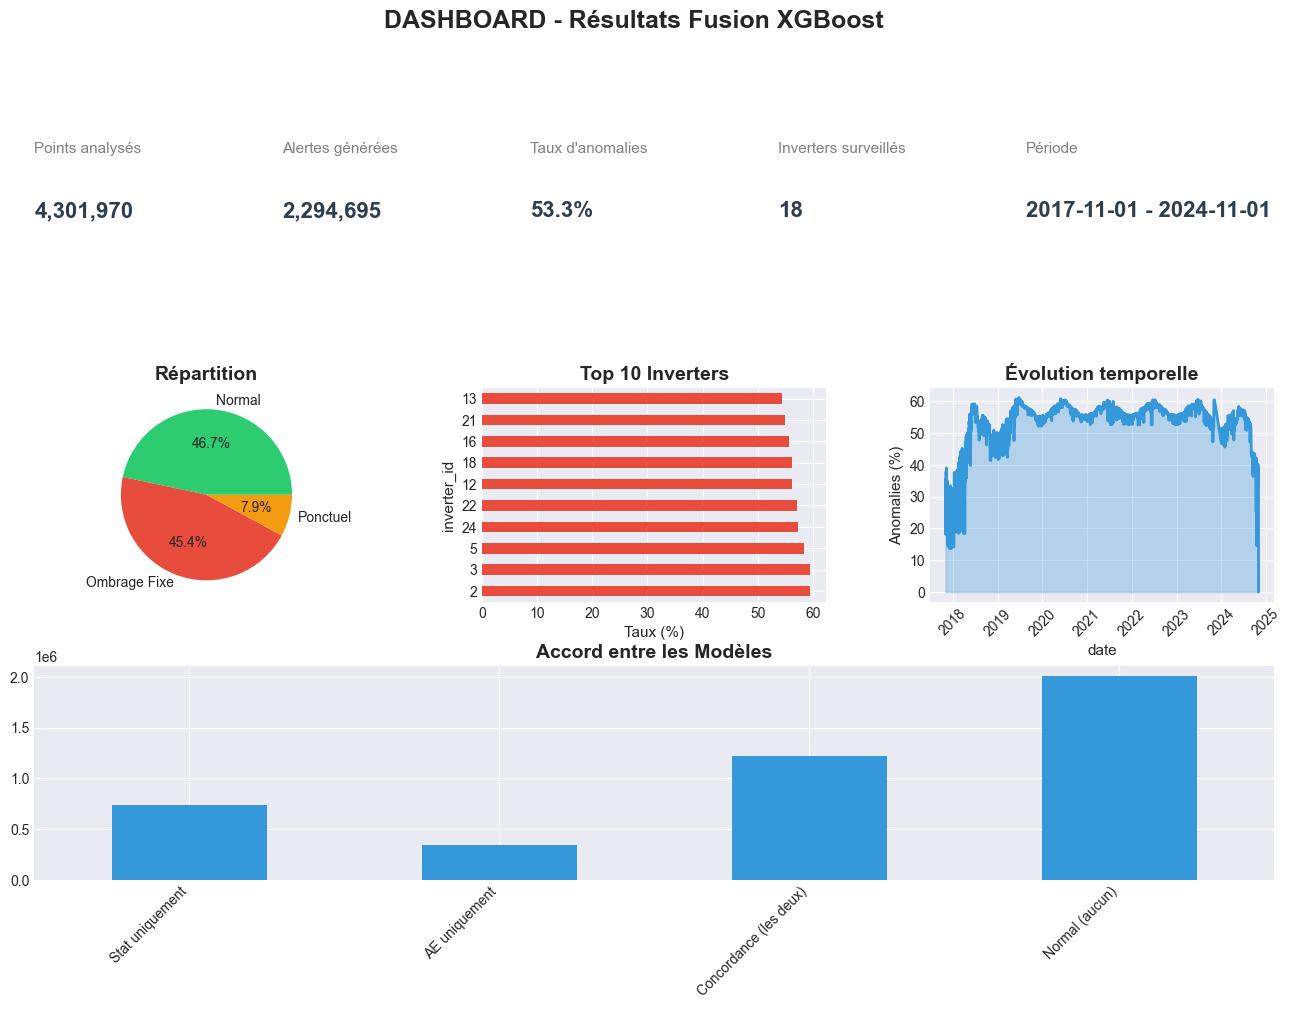


📝 Génération rapport texte...
   ✅ Sauvegardé: RAPPORT.txt

✅ VISUALISATIONS TERMINÉES

📁 Tous les fichiers sont dans le dossier: viz_fusion/

📊 Graphiques générés:
   01 - Distribution des prédictions
   02 - Comparaison Stat vs AE
   03 - Évolution temporelle
   04 - Top inverters problématiques
   05 - Distribution des scores
   06 - Heatmap horaire
   07 - Matrice de confusion
   08 - Timeline des alertes
   09 - Confiance des prédictions
   10 - Dashboard récapitulatif ⭐

📝 Rapport texte: RAPPORT.txt


In [10]:
"""
VISUALISATION RÉSULTATS FUSION XGBOOST
Génère des graphiques pour présentation PPT
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

# Créer dossier outputs
import os
os.makedirs('viz_fusion', exist_ok=True)

print("📊 Chargement des résultats...")

# Charger les résultats
df = pd.read_csv('fusion_results_optimized.csv', parse_dates=['timestamp'])
alertes = pd.read_csv('fusion_alertes_optimized.csv', parse_dates=['timestamp'])

print(f"✅ {len(df):,} lignes | {len(alertes):,} alertes")

# ============================================================================
# 1. VUE D'ENSEMBLE - DISTRIBUTION DES PRÉDICTIONS
# ============================================================================

print("\n📈 Graphique 1: Distribution des prédictions...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
pred_counts = df['pred_type'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#95a5a6']
axes[0].pie(pred_counts.values, labels=pred_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors[:len(pred_counts)])
axes[0].set_title('Distribution des Prédictions', fontsize=16, fontweight='bold')

# Bar chart avec valeurs
pred_counts.plot(kind='barh', ax=axes[1], color=colors[:len(pred_counts)])
axes[1].set_title('Nombre de Points par Catégorie', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Nombre de points')
for i, v in enumerate(pred_counts.values):
    axes[1].text(v + len(df)*0.01, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_fusion/01_distribution_predictions.png', dpi=300, bbox_inches='tight')
print("   ✅ Sauvegardé: 01_distribution_predictions.png")
plt.show()
plt.close()

# ============================================================================
# 2. COMPARAISON MODÈLES STAT vs AE
# ============================================================================

print("\n📈 Graphique 2: Comparaison Stat vs AE...")

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

comparison_data = pd.DataFrame({
    'Stat uniquement': [((df['anomaly_stat'] == 1) & (df['anomaly_ae'] == 0)).sum()],
    'AE uniquement': [((df['anomaly_stat'] == 0) & (df['anomaly_ae'] == 1)).sum()],
    'Concordance (les deux)': [((df['anomaly_stat'] == 1) & (df['anomaly_ae'] == 1)).sum()],
    'Normal (aucun)': [((df['anomaly_stat'] == 0) & (df['anomaly_ae'] == 0)).sum()]
}, index=[0]).T

comparison_data.plot(kind='bar', ax=ax, color=['#3498db', '#9b59b6', '#e74c3c', '#2ecc71'], legend=False)
ax.set_title('Accord entre Modèle Statistique et Auto-Encodeur', fontsize=16, fontweight='bold')
ax.set_ylabel('Nombre de points')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

for i, v in enumerate(comparison_data.values):
    ax.text(i, v[0] + len(df)*0.01, f'{v[0]:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_fusion/02_comparaison_modeles.png', dpi=300, bbox_inches='tight')
print("   ✅ Sauvegardé: 02_comparaison_modeles.png")
plt.show()
plt.close()

# ============================================================================
# 3. ÉVOLUTION TEMPORELLE DES ANOMALIES
# ============================================================================

print("\n📈 Graphique 3: Évolution temporelle...")

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Grouper par jour
df['date'] = df['timestamp'].dt.date
daily_anomalies = df[df['pred_class'].isin([1, 2])].groupby('date').size()
daily_total = df.groupby('date').size()
daily_rate = (daily_anomalies / daily_total * 100).fillna(0)

daily_rate.plot(ax=ax, linewidth=2, color='#e74c3c')
ax.fill_between(daily_rate.index, daily_rate.values, alpha=0.3, color='#e74c3c')
ax.set_title('Taux d\'Anomalies Détectées par Jour', fontsize=16, fontweight='bold')
ax.set_ylabel('Pourcentage d\'anomalies (%)')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)

# Moyenne mobile
window = 7
if len(daily_rate) > window:
    rolling_mean = daily_rate.rolling(window=window, center=True).mean()
    ax.plot(rolling_mean.index, rolling_mean.values, '--', linewidth=2.5, 
            color='#2c3e50', label=f'Moyenne mobile {window}j')
    ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('viz_fusion/03_evolution_temporelle.png', dpi=300, bbox_inches='tight')
print("   ✅ Sauvegardé: 03_evolution_temporelle.png")
plt.show()
plt.close()

# ============================================================================
# 4. ANALYSE PAR INVERTER
# ============================================================================

print("\n📈 Graphique 4: Top inverters à problèmes...")

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Calculer taux d'anomalies par inverter
inv_anomalies = df[df['pred_class'].isin([1, 2])].groupby('inverter_id').size()
inv_total = df.groupby('inverter_id').size()
inv_rate = (inv_anomalies / inv_total * 100).fillna(0).sort_values(ascending=False)

# Top 15
top_inv = inv_rate.head(15)
colors_inv = ['#e74c3c' if x > 50 else '#f39c12' if x > 25 else '#3498db' for x in top_inv.values]

top_inv.plot(kind='barh', ax=ax, color=colors_inv)
ax.set_title('Top 15 Onduleurs avec le Plus d\'Anomalies', fontsize=16, fontweight='bold')
ax.set_xlabel('Taux d\'anomalies (%)')
ax.set_ylabel('Inverter ID')

for i, v in enumerate(top_inv.values):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

# Légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Critique (>50%)'),
    Patch(facecolor='#f39c12', label='Élevé (25-50%)'),
    Patch(facecolor='#3498db', label='Modéré (<25%)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('viz_fusion/04_top_inverters.png', dpi=300, bbox_inches='tight')
print("   ✅ Sauvegardé: 04_top_inverters.png")
plt.show()
plt.close()

# ============================================================================
# 5. DISTRIBUTION DES SCORES
# ============================================================================

print("\n📈 Graphique 5: Distribution des scores...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score Stat
for pred_class, color, label in [(0, '#2ecc71', 'Normal'), 
                                   (1, '#e74c3c', 'Ombrage'), 
                                   (2, '#f39c12', 'Ponctuel')]:
    data = df[df['pred_class'] == pred_class]['score_stat'].dropna()
    if len(data) > 0:
        axes[0].hist(data, bins=50, alpha=0.6, label=label, color=color)

axes[0].set_title('Distribution Score Statistique', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Fréquence')
axes[0].legend()
axes[0].set_yscale('log')

# Score AE
for pred_class, color, label in [(0, '#2ecc71', 'Normal'), 
                                   (1, '#e74c3c', 'Ombrage'), 
                                   (2, '#f39c12', 'Ponctuel')]:
    data = df[df['pred_class'] == pred_class]['score_ae'].dropna()
    if len(data) > 0:
        axes[1].hist(data, bins=50, alpha=0.6, label=label, color=color)

axes[1].set_title('Distribution Score Auto-Encodeur', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Fréquence')
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('viz_fusion/05_distribution_scores.png', dpi=300, bbox_inches='tight')
print("   ✅ Sauvegardé: 05_distribution_scores.png")
plt.show()
plt.close()

# ============================================================================
# 6. HEATMAP HORAIRE
# ============================================================================

print("\n📈 Graphique 6: Heatmap horaire...")

# Extraire heure et jour de la semaine
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek

# Calculer taux d'anomalies par heure et jour
pivot_data = df.groupby(['dayofweek', 'hour']).apply(
    lambda x: (x['pred_class'].isin([1, 2])).sum() / len(x) * 100
).unstack(fill_value=0)

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

sns.heatmap(pivot_data, cmap='YlOrRd', annot=False, fmt='.1f', 
            cbar_kws={'label': 'Taux d\'anomalies (%)'}, ax=ax)
ax.set_title('Taux d\'Anomalies par Heure et Jour de la Semaine', fontsize=16, fontweight='bold')
ax.set_xlabel('Heure de la journée')
ax.set_ylabel('Jour de la semaine')
ax.set_yticklabels(['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim'], rotation=0)

plt.tight_layout()
plt.savefig('viz_fusion/06_heatmap_horaire.png', dpi=300, bbox_inches='tight')
print("   ✅ Sauvegardé: 06_heatmap_horaire.png")
plt.show()
plt.close()

# ============================================================================
# 7. MATRICE DE CONFUSION STAT vs AE vs FUSION
# ============================================================================

print("\n📈 Graphique 7: Matrice de confusion...")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Créer matrice: lignes=Stat, colonnes=AE, couleur=Fusion
confusion_data = pd.crosstab(
    df['anomaly_stat'].map({0: 'Normal', 1: 'Anomalie'}),
    df['anomaly_ae'].map({0: 'Normal', 1: 'Anomalie'}),
    normalize='all'
) * 100

sns.heatmap(confusion_data, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Pourcentage (%)'}, ax=ax, linewidths=2)
ax.set_title('Accord Statistique vs Auto-Encodeur', fontsize=16, fontweight='bold')
ax.set_xlabel('Auto-Encodeur', fontsize=12)
ax.set_ylabel('Modèle Statistique', fontsize=12)

plt.tight_layout()
plt.savefig('viz_fusion/07_matrice_confusion.png', dpi=300, bbox_inches='tight')
print("   ✅ Sauvegardé: 07_matrice_confusion.png")
plt.show()
plt.close()

# ============================================================================
# 8. ALERTES - TIMELINE
# ============================================================================

print("\n📈 Graphique 8: Timeline des alertes...")

if len(alertes) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    
    # Grouper alertes par jour et type
    alertes['date'] = alertes['timestamp'].dt.date
    alert_pivot = alertes.groupby(['date', 'pred_type']).size().unstack(fill_value=0)
    
    alert_pivot.plot(kind='area', stacked=True, ax=ax, 
                     color=['#e74c3c', '#f39c12'], alpha=0.7)
    ax.set_title('Volume d\'Alertes par Jour', fontsize=16, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Nombre d\'alertes')
    ax.legend(title='Type', loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('viz_fusion/08_timeline_alertes.png', dpi=300, bbox_inches='tight')
    print("   ✅ Sauvegardé: 08_timeline_alertes.png")
    plt.show()
    plt.close()

# ============================================================================
# 9. CONFIDENCE DES PRÉDICTIONS
# ============================================================================

print("\n📈 Graphique 9: Distribution de la confiance...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme général
axes[0].hist(df['pred_proba'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(0.6, color='red', linestyle='--', linewidth=2, label='Seuil alertes (60%)')
axes[0].set_title('Distribution de la Confiance des Prédictions', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Probabilité de prédiction')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Par classe
for pred_class, color, label in [(0, '#2ecc71', 'Normal'), 
                                   (1, '#e74c3c', 'Ombrage'), 
                                   (2, '#f39c12', 'Ponctuel')]:
    data = df[df['pred_class'] == pred_class]['pred_proba']
    if len(data) > 0:
        axes[1].hist(data, bins=30, alpha=0.6, label=label, color=color)

axes[1].set_title('Confiance par Type de Prédiction', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Probabilité de prédiction')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.savefig('viz_fusion/09_confiance_predictions.png', dpi=300, bbox_inches='tight')
print("   ✅ Sauvegardé: 09_confiance_predictions.png")
plt.show()
plt.close()

# ============================================================================
# 10. DASHBOARD RÉCAPITULATIF
# ============================================================================

print("\n📈 Graphique 10: Dashboard récapitulatif...")

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. KPIs en haut
ax1 = fig.add_subplot(gs[0, :])
ax1.axis('off')

kpis = {
    'Points analysés': f"{len(df):,}",
    'Alertes générées': f"{len(alertes):,}",
    'Taux d\'anomalies': f"{len(df[df['pred_class'].isin([1,2])])/len(df)*100:.1f}%",
    'Inverters surveillés': f"{df['inverter_id'].nunique()}",
    'Période': f"{df['timestamp'].min().date()} - {df['timestamp'].max().date()}"
}

y_pos = 0.8
for i, (key, value) in enumerate(kpis.items()):
    x_pos = i * 0.2
    ax1.text(x_pos, y_pos, key, fontsize=11, ha='left', fontweight='normal', color='gray')
    ax1.text(x_pos, y_pos-0.3, value, fontsize=16, ha='left', fontweight='bold', color='#2c3e50')

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# 2. Pie chart
ax2 = fig.add_subplot(gs[1, 0])
pred_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=colors[:len(pred_counts)])
ax2.set_ylabel('')
ax2.set_title('Répartition', fontweight='bold')

# 3. Top inverters
ax3 = fig.add_subplot(gs[1, 1])
top_inv.head(10).plot(kind='barh', ax=ax3, color='#e74c3c')
ax3.set_title('Top 10 Inverters', fontweight='bold')
ax3.set_xlabel('Taux (%)')

# 4. Évolution
ax4 = fig.add_subplot(gs[1, 2])
daily_rate.plot(ax=ax4, color='#3498db', linewidth=2)
ax4.fill_between(daily_rate.index, daily_rate.values, alpha=0.3, color='#3498db')
ax4.set_title('Évolution temporelle', fontweight='bold')
ax4.set_ylabel('Anomalies (%)')
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45)

# 5. Comparaison modèles
ax5 = fig.add_subplot(gs[2, :])
comparison_data.plot(kind='bar', ax=ax5, color=['#3498db', '#9b59b6', '#e74c3c', '#2ecc71'])
ax5.set_title('Accord entre les Modèles', fontweight='bold')
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45, ha='right')
ax5.legend().remove()

plt.suptitle('DASHBOARD - Résultats Fusion XGBoost', fontsize=18, fontweight='bold', y=0.98)
plt.savefig('viz_fusion/10_dashboard_recap.png', dpi=300, bbox_inches='tight')
print("   ✅ Sauvegardé: 10_dashboard_recap.png")
plt.show()
plt.close()

# ============================================================================
# GÉNÉRATION RAPPORT TEXTE
# ============================================================================

print("\n📝 Génération rapport texte...")

rapport = f"""
{'='*70}
RAPPORT DE FUSION - MODÈLE XGBOOST
{'='*70}

📊 STATISTIQUES GÉNÉRALES
{'─'*70}
Points analysés          : {len(df):,}
Période d'analyse        : {df['timestamp'].min()} à {df['timestamp'].max()}
Inverters surveillés     : {df['inverter_id'].nunique()}

🎯 RÉSULTATS DE PRÉDICTION
{'─'*70}
"""

for pred_type, count in pred_counts.items():
    pct = count / len(df) * 100
    rapport += f"{pred_type:20s} : {count:>10,} ({pct:>5.1f}%)\n"

rapport += f"""
🚨 ALERTES GÉNÉRÉES
{'─'*70}
Total alertes            : {len(alertes):,}
Taux d'alertes           : {len(alertes)/len(df)*100:.2f}%

Répartition :
"""

if len(alertes) > 0:
    for alert_type, count in alertes['pred_type'].value_counts().items():
        pct = count / len(alertes) * 100
        rapport += f"  {alert_type:20s} : {count:>8,} ({pct:>5.1f}%)\n"

rapport += f"""
📈 ACCORD ENTRE MODÈLES
{'─'*70}
Concordance (Stat + AE)  : {len(df[(df['anomaly_stat']==1) & (df['anomaly_ae']==1)]):,}
Stat uniquement          : {len(df[(df['anomaly_stat']==1) & (df['anomaly_ae']==0)]):,}
AE uniquement            : {len(df[(df['anomaly_stat']==0) & (df['anomaly_ae']==1)]):,}
Normal (aucun)           : {len(df[(df['anomaly_stat']==0) & (df['anomaly_ae']==0)]):,}

🔝 TOP 5 INVERTERS À RISQUE
{'─'*70}
"""

for inv_id, rate in inv_rate.head(5).items():
    total = inv_total[inv_id]
    anomalies = inv_anomalies.get(inv_id, 0)
    rapport += f"  {str(inv_id):8s} : {rate:>5.1f}% ({anomalies:,} / {total:,} points)\n"

rapport += f"""
{'='*70}
Rapport généré le {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*70}
"""

with open('viz_fusion/RAPPORT.txt', 'w', encoding='utf-8') as f:
    f.write(rapport)

print("   ✅ Sauvegardé: RAPPORT.txt")

# ============================================================================
# RÉSUMÉ
# ============================================================================

print("\n" + "="*70)
print("✅ VISUALISATIONS TERMINÉES")
print("="*70)
print(f"\n📁 Tous les fichiers sont dans le dossier: viz_fusion/")
print(f"\n📊 Graphiques générés:")
print("   01 - Distribution des prédictions")
print("   02 - Comparaison Stat vs AE")
print("   03 - Évolution temporelle")
print("   04 - Top inverters problématiques")
print("   05 - Distribution des scores")
print("   06 - Heatmap horaire")
print("   07 - Matrice de confusion")
print("   08 - Timeline des alertes")
print("   09 - Confiance des prédictions")
print("   10 - Dashboard récapitulatif ⭐")
print(f"\n📝 Rapport texte: RAPPORT.txt")
print("="*70)